# 도's Pick! · 1번

대회 시간: **2026-10-09 08:50~10:20 (한국 시간)**. 시작 전에는 운영자 개방 승인이 필요합니다.

MAICON 모의고사 1회차 | 문제 1
군사 감시 이미지 기반 주요 차량 수량 예측

[문제 설명]
군사 감시 체계에서 확보한 이미지에는 전차, 군용 트럭, 기타 군용 차량, 민간 차량 등이 등장합니다. 주어진 학습 이미지와 객체 위치·종류 주석을 이용하여 이미지 속 주요 차량을 탐지하는 모델을 구축하세요. 테스트 이미지마다 지정된 4종의 객체가 각각 몇 대 있는지 예측해야 합니다.

[제공 데이터]
- train/images/: 학습 이미지
- train/labels/: YOLO 형식의 객체 탐지 정답(클래스 ID, 바운딩박스)
- test/images/: 정답이 공개되지 않은 테스트 이미지
- sample_submission.csv: 제출 예시
- data.yaml: 클래스 ID와 클래스 이름의 대응 관계

[예측 대상]
- military_tank: 전차 수
- military_truck: 군용 트럭 수
- military_vehicle: 기타 군용 차량 수
- civilian_vehicle: 민간 차량 수
※ 나머지 클래스는 이번 문제의 채점 대상이 아닙니다. 객체 1개는 가장 적절한 클래스 1개로만 셉니다.

[모델 및 구현 조건]
1. YOLOv8 계열의 사전학습 객체 탐지 모델을 사용하고, 제공된 학습 데이터로 전이학습을 수행하세요.
2. 입력 크기, 데이터 증강, 학습 횟수, confidence threshold, NMS 설정 등은 자유롭게 조정할 수 있습니다.
3. 테스트 정답 파일을 직접 읽거나 외부 정답을 가져오는 행위는 허용하지 않습니다.

[평가]
이미지별 '정확한 수량 일치율(Exact Count Accuracy)'을 사용합니다.
한 이미지에서 4개 클래스의 예측 수량이 모두 정답과 같을 때만 해당 이미지를 1점, 그렇지 않으면 0점으로 계산합니다. 최종 점수는 전체 테스트 이미지에서의 평균입니다. 높을수록 좋습니다.

[제출 형식]
파일명: submission.csv
컬럼: image_id,military_tank,military_truck,military_vehicle,civilian_vehicle
- image_id는 sample_submission.csv와 동일한 이미지 식별자를 사용하세요.
- 모든 수량은 0 이상의 정수여야 합니다.
- 테스트 이미지마다 정확히 한 행을 작성하고, sample_submission.csv의 행 순서를 유지하세요.

[원본 데이터]
Military Assets Dataset (12 Classes - Yolo8 Format)
https://www.kaggle.com/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format

[태그]
#이미지분석 #YOLOv8 #전이학습 #객체탐지 #수량예측

## 이번 대회의 제공 구성
- 공개 학습: `data/train/images/` 640장과 `data/train/labels/` YOLO 라벨
- 공개 검증: `data/val/images/` 160장과 `data/val/labels/` YOLO 라벨
- 최종 평가: `data/test/images/` 200장. 최종 평가 라벨은 제공하지 않습니다.
- 동일 이미지 바이트가 학습·검증·평가에 중복되지 않도록 선정했습니다.
- 원본의 비정상 라벨이 있는 이미지는 선정에서 제외했습니다.
- 원본 12개 클래스 중 지정 4개만 남기고 라벨을 다음과 같이 재매핑했습니다.

| 공개 class ID | 클래스 | 원본 class ID |
|---|---|---|
| 0 | military_tank | 2 |
| 1 | military_truck | 3 |
| 2 | military_vehicle | 4 |
| 3 | civilian_vehicle | 7 |

각 라벨 행은 `class_id x_center y_center width height`이며 좌표는 이미지 크기에 대한 0~1 정규화 값입니다. 빈 라벨 파일은 지정 4종 객체가 없는 이미지입니다. 다른 객체는 이번 학습 라벨과 수량 평가에서 제외합니다.
`data/data.yaml`에는 실제 경로와 4개 클래스의 대응이 있습니다. 데이터는 읽기 전용입니다. YOLO 학습 출력·가중치·캐시는 작업 폴더에 저장하세요.
공개 사전학습 가중치 `yolov8n.pt`를 미리 준비했습니다. Python의 `ultralytics`, CPU PyTorch도 설치되어 있습니다. 제공된 데이터로 전이학습 후 사용하세요.

## 공통 제출 검증
- 최종 파일: `/workspace/problem01/submission.csv`
- 정확한 컬럼 순서: `image_id,military_tank,military_truck,military_vehicle,civilian_vehicle`
- sample_submission의 모든 ID를 정확히 한 번씩, 같은 순서로 제출합니다. 누락·추가·중복·순서 변경은 오류입니다.
- UTF-8 또는 UTF-8 BOM CSV, 쉼표 구분, 헤더 포함. 빈 필드·NaN·무한대·깨진 CSV는 오류입니다.
- 1번 수량은 0 이상의 정수, 2번은 지정된 5개 문자열, 3번은 문자열 `0` 또는 `1` 형태의 정수 클래스입니다.
- 유효하지 않은 제출은 해당 문제 0점·ERROR로 처리합니다.
- 문제 점수는 **100 × raw 평가 지표**입니다. 정답과 정확히 같으면 100점이며 세 문제 합계는 300점입니다.
- 제공 데이터는 읽기 전용이며, 가공 결과·모델·제출은 작업공간에 저장합니다.


classes: {0: 'military_tank', 1: 'military_truck', 2: 'military_vehicle', 3: 'civilian_vehicle'}
train/val/test: 640 160 200


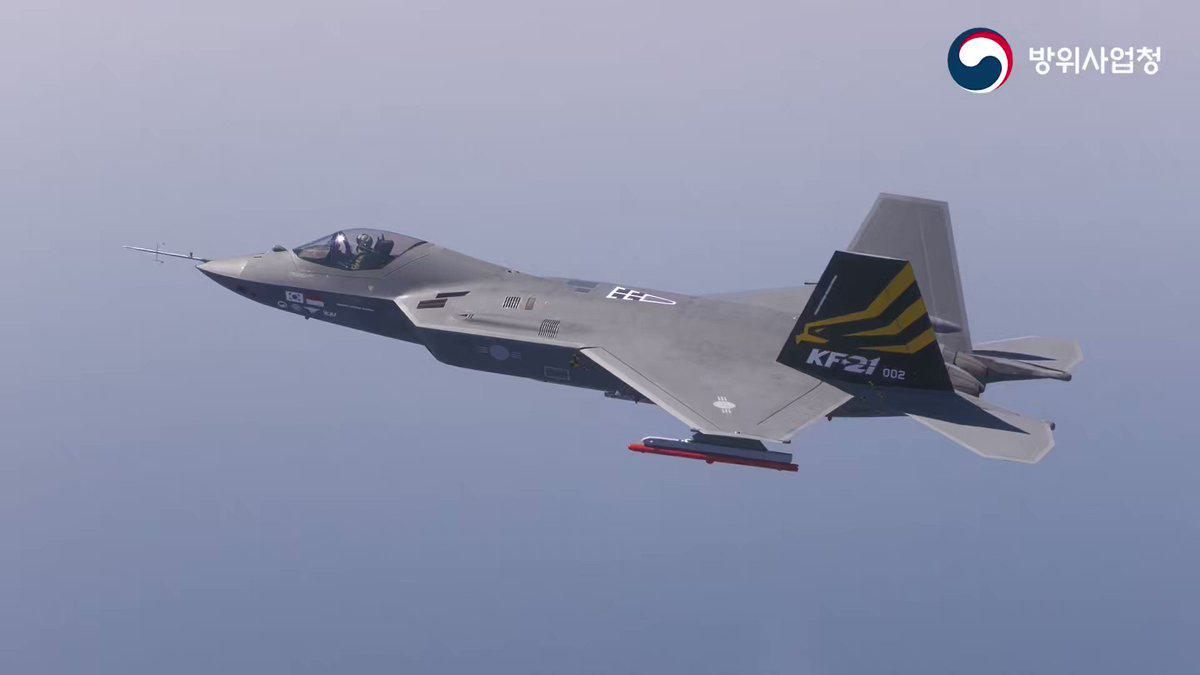

,image_id,military_tank,military_truck,military_vehicle,civilian_vehicle
0,test_0001.jpg,0,0,0,0
1,test_0002.jpg,0,0,0,0
2,test_0003.jpg,0,0,0,0
3,test_0004.jpg,0,0,0,0
4,test_0005.jpg,0,0,0,0


In [1]:
from pathlib import Path
import pandas as pd
import yaml
from PIL import Image
DATA_DIR = Path("data")
with (DATA_DIR / "data.yaml").open() as f:
    config = yaml.safe_load(f)
print("classes:", config["names"])
sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
print("train/val/test:", *[len(list((DATA_DIR / split / "images").iterdir())) for split in ["train", "val", "test"]])
display(Image.open(next((DATA_DIR / "train/images").iterdir())))
display(sample.head())


## 풀이: YOLOv8n 전이학습 + 검출 개수 세기
- **방법**: 사전학습 `yolov8n.pt`를 제공 학습 이미지 640장으로 전이학습한 뒤, 테스트 이미지에서 검출된 박스를 클래스별로 세어 수량으로 제출합니다.
- **확정 설정**: 학습 imgsz 640, batch 16, 40에폭, seed 0. 추론 imgsz 640, NMS iou 0.6, `agnostic_nms=True`, conf 0.3.
- **conf 선택 근거**: 검증 160장에서 conf 0.15~0.6을 비교한 결과 0.3이 가장 높았습니다(아래 표). 검증 160장으로 conf를 고르고 점수도 같이 봤기 때문에 **낙관적인 추정**입니다.
- **정직한 기록**: 학습은 개발 PC GPU에서 별도 스크립트로 1회 했고, 그 가중치(`best.pt`)가 있으면 이 노트북은 재학습을 건너뛰고 그대로 불러옵니다(가중치가 없으면 같은 설정으로 학습). 서버(CPU 2코어)에서의 학습 시간은 측정하지 않았습니다.

In [2]:
import sys, json, os, glob, time, hashlib
from pathlib import Path
import numpy as np, pandas as pd

try:
    import ultralytics
except ImportError:
    # 응시 환경에 없으면 설치 (용량·시간은 14.6 예산에 포함). 설치 후 이 셀을 다시 실행
    !pip install -q ultralytics
    import ultralytics
import torch
from ultralytics import YOLO
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__, "| cuda", torch.cuda.is_available())

DEVICE = 0 if torch.cuda.is_available() else "cpu"        # GPU 가 없으면 CPU 로 같은 코드 실행
NAMES = ["military_tank", "military_truck", "military_vehicle", "civilian_vehicle"]
# 제공 data.yaml 의 경로는 대회 서버용(/workspace/...)이라, 현재 폴더 기준 절대경로로 새 yaml 을 만든다 (원본 data 는 수정하지 않음)
DATA_ABS = os.path.abspath("data")
with open("data_work.yaml", "w", encoding="utf-8") as f:
    f.write(f"path: {json.dumps(DATA_ABS)}\ntrain: train/images\nval: val/images\nnames:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(NAMES)))
print(open("data_work.yaml", encoding="utf-8").read())

ultralytics 8.4.174 | torch 2.14.1+cu126 | cuda True
path: "C:\\Users\\User\\Desktop\\root\\docker11\\notebooks\\MAICON_hub\\training_s\\26_10_09\\all_data\\problem01\\data"
train: train/images
val: val/images
names:
  0: military_tank
  1: military_truck
  2: military_vehicle
  3: civilian_vehicle



In [3]:
# ---- 전이학습 (확정 설정). 확정 가중치가 이미 있으면 재학습을 건너뛴다 ----
CONFIRMED = ["runs/detect/training_runs/gpu640/weights/best.pt", "training_runs/gpu640/weights/best.pt"]
found = [p for p in CONFIRMED if os.path.exists(p)]
if found:
    WEIGHTS = found[0]
    print("확정 가중치 사용(재학습 건너뜀):", WEIGHTS)
else:
    t0 = time.time()
    kw = dict(time=0.4) if DEVICE == "cpu" else {}          # CPU 에서는 시간 상한(0.4시간)을 둔다 -> 확정 모델과 달라질 수 있음
    res = YOLO("yolov8n.pt").train(data="data_work.yaml", epochs=40, imgsz=640, batch=16, workers=0, device=DEVICE,
                                   project="training_runs", name="work_final", seed=0, deterministic=True, plots=False,
                                   verbose=False, patience=10, exist_ok=True, **kw)
    WEIGHTS = str(res.save_dir / "weights" / "best.pt")
    print(f"학습 완료 {time.time() - t0:.0f}s ->", WEIGHTS)

확정 가중치 사용(재학습 건너뜀): runs/detect/training_runs/gpu640/weights/best.pt


In [4]:
# ---- 검증 160장: 이미지별 4개 수량이 모두 맞아야 1점 (Exact Count Accuracy) ----
model = YOLO(WEIGHTS)
IMGSZ, IOU, AGNOSTIC = 640, 0.6, True

def gt_counts(img):
    p = Path(img); lab = p.parents[1] / "labels" / (p.stem + ".txt")
    c = [0] * 4
    for l in open(lab).read().splitlines():
        if l.strip(): c[int(l.split()[0])] += 1
    return tuple(c)

def predict_boxes(paths, bs=40):
    out = []
    for i in range(0, len(paths), bs):
        for r in model.predict(paths[i:i + bs], imgsz=IMGSZ, conf=0.05, iou=IOU, agnostic_nms=AGNOSTIC, device=DEVICE, verbose=False):
            out.append((r.boxes.cls.cpu().numpy().astype(int), r.boxes.conf.cpu().numpy()))
    return out

def counts(box, thr): return tuple(int(((box[0] == c) & (box[1] >= thr)).sum()) for c in range(4))

val_imgs = sorted(glob.glob("data/val/images/*")); G = [gt_counts(p) for p in val_imgs]; VB = predict_boxes(val_imgs)
print("검증 이미지:", len(val_imgs), "| 전부 0 으로 찍었을 때 정확도: %.4f" % np.mean([g == (0, 0, 0, 0) for g in G]))
tab = {t: np.mean([counts(b, t) == g for b, g in zip(VB, G)]) for t in (0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6)}
print("conf 별 정확한 수량 일치율:", {k: round(v, 4) for k, v in tab.items()})
CONF = 0.3
print("선택 conf =", CONF, "-> 검증 일치율 %.4f (conf 를 같은 데이터로 골랐으므로 낙관적)" % tab[CONF])

검증 이미지: 160 | 전부 0 으로 찍었을 때 정확도: 0.3812
conf 별 정확한 수량 일치율: {0.15: np.float64(0.5625), 0.2: np.float64(0.5875), 0.25: np.float64(0.5938), 0.3: np.float64(0.6188), 0.35: np.float64(0.6062), 0.4: np.float64(0.6062), 0.5: np.float64(0.6), 0.6: np.float64(0.5938)}
선택 conf = 0.3 -> 검증 일치율 0.6188 (conf 를 같은 데이터로 골랐으므로 낙관적)


In [5]:
# ---- 테스트 이미지 수량 예측 -> submission.csv ----
sample = pd.read_csv("data/sample_submission.csv")
paths = {os.path.basename(p): p for p in glob.glob("data/test/images/*")}
assert set(sample.image_id) == set(paths), "test 이미지와 sample_submission ID 가 다름"
TB = predict_boxes([paths[i] for i in sample.image_id])
sub = pd.DataFrame([[i] + list(counts(b, CONF)) for i, b in zip(sample.image_id, TB)], columns=["image_id"] + NAMES)
assert sub.image_id.tolist() == sample.image_id.tolist() and list(sub.columns) == list(sample.columns)
assert (sub[NAMES] >= 0).all().all() and not sub.isna().any().any()
sub.to_csv("submission.csv", index=False)
print(sub.shape, "클래스별 합계:", sub[NAMES].sum().to_dict(), "| 모두 0인 이미지 비율 %.3f (검증 정답은 %.3f)" % ((sub[NAMES].sum(axis=1) == 0).mean(), np.mean([g == (0, 0, 0, 0) for g in G])))
sub.head()

(200, 5) 클래스별 합계: {'military_tank': 109, 'military_truck': 20, 'military_vehicle': 9, 'civilian_vehicle': 23} | 모두 0인 이미지 비율 0.620 (검증 정답은 0.381)


,image_id,military_tank,military_truck,military_vehicle,civilian_vehicle
0,test_0001.jpg,0,0,0,0
1,test_0002.jpg,3,0,0,0
2,test_0003.jpg,0,0,0,0
3,test_0004.jpg,0,0,0,0
4,test_0005.jpg,1,0,0,0


## 최종 제출 확인
아래 셀은 submission.csv를 직접 만든 뒤 실행하세요.

In [6]:
submission = pd.read_csv("submission.csv")
assert submission.columns.tolist() == sample.columns.tolist()
assert submission.iloc[:, 0].tolist() == sample.iloc[:, 0].tolist()
assert submission.iloc[:, 0].is_unique and not submission.isna().any().any()
print("제출 양식·ID·순서 확인 완료:", submission.shape)


제출 양식·ID·순서 확인 완료: (200, 5)
